# DCM Converter Curve Plot

This notebook plots `g_minor` and `g_major` for:
- `MappedConductanceConverter(profile="1month")` (`DCM`)
- `MappedConductanceConverter(profile="1year")` (`DCM_1yr`)


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "tests" else Path.cwd().resolve()
sys.path.append(str(repo_root / "src"))

from module.g_converter import MappedConductanceConverter

In [5]:
def extract_curves(converter, num_points=501):
    """Use positive normalized weights so gp=g_major and gm=g_minor."""
    abs_w = torch.linspace(-1.0, 1.0, num_points)
    conductances, _ = converter.convert_to_conductances(abs_w)
    g_major = conductances[0].detach().cpu().numpy()
    g_minor = conductances[1].detach().cpu().numpy()
    return abs_w.detach().cpu().numpy(), g_minor, g_major


def plot_converter(ax, converter, title):
    abs_w, g_minor, g_major = extract_curves(converter)
    ax.plot(abs_w, g_minor, label="g_minor", linewidth=2)
    ax.plot(abs_w, g_major, label="g_major", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("abs_w")
    ax.set_ylabel("Conductance (uS)")
    ax.grid(True, alpha=0.3)
    ax.legend()

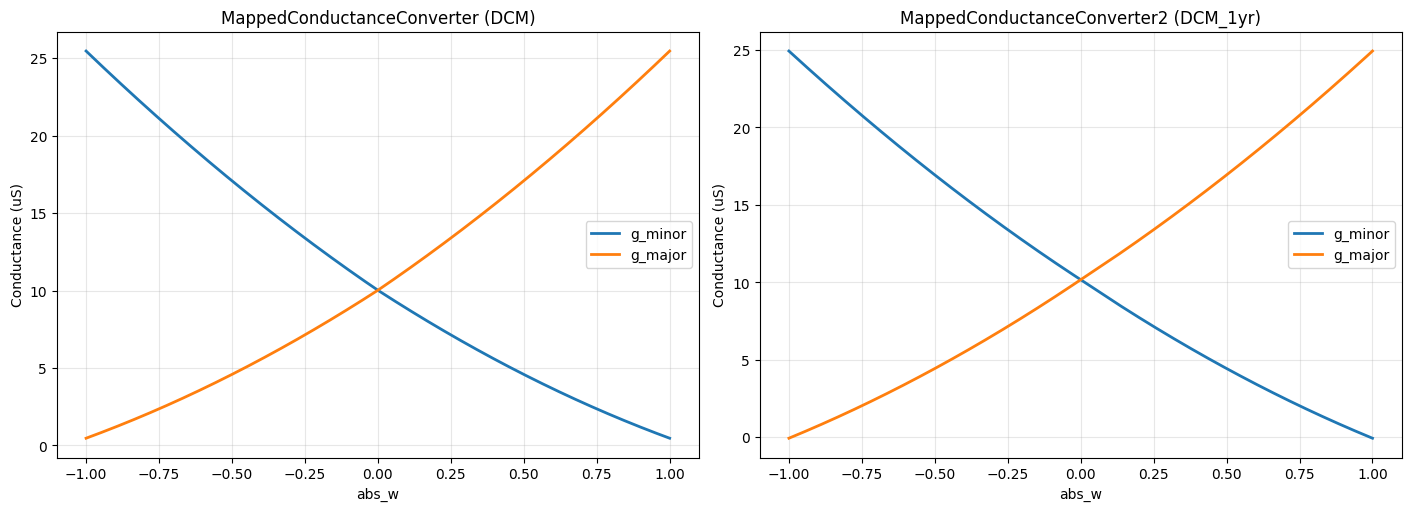

In [6]:
converter_dcm = MappedConductanceConverter(g_max=25.0, g_min=0.0, distortion_f=0.0, profile="1month")
converter_dcm_1yr = MappedConductanceConverter(g_max=25.0, g_min=0.0, distortion_f=0.0, profile="1year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plot_converter(axes[0], converter_dcm, "MappedConductanceConverter (DCM)")
plot_converter(axes[1], converter_dcm_1yr, "MappedConductanceConverter (DCM_1yr profile)")
plt.show()

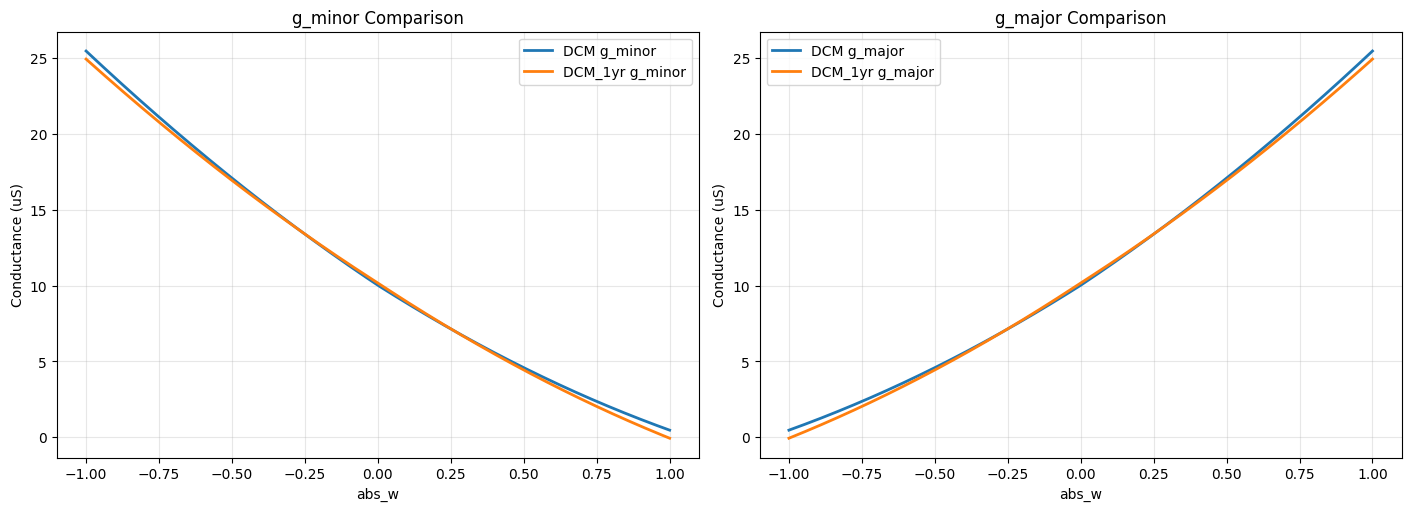

In [7]:
abs_w_1, g_minor_1, g_major_1 = extract_curves(converter_dcm)
abs_w_2, g_minor_2, g_major_2 = extract_curves(converter_dcm_1yr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(abs_w_1, g_minor_1, label="DCM g_minor", linewidth=2)
axes[0].plot(abs_w_2, g_minor_2, label="DCM_1yr g_minor", linewidth=2)
axes[0].set_title("g_minor Comparison")
axes[0].set_xlabel("abs_w")
axes[0].set_ylabel("Conductance (uS)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(abs_w_1, g_major_1, label="DCM g_major", linewidth=2)
axes[1].plot(abs_w_2, g_major_2, label="DCM_1yr g_major", linewidth=2)
axes[1].set_title("g_major Comparison")
axes[1].set_xlabel("abs_w")
axes[1].set_ylabel("Conductance (uS)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()